In [ ]:
# Initialize Otter
import otter
grader = otter.Notebook("projB2.ipynb")

In [ ]:
# Run this cell to suppress all FutureWarnings
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

In [ ]:
import numpy as np
import pandas as pd
import sys

import matplotlib.pyplot as plt
%matplotlib inline

import seaborn as sns
sns.set(style = "whitegrid",
        color_codes = True,
        font_scale = 1.5)

from datetime import datetime
from IPython.display import display, HTML

In [ ]:
import zipfile
with zipfile.ZipFile('spam_ham_data.zip') as item:
    item.extractall()

In [ ]:
original_training_data = pd.read_csv('train.csv')
test = pd.read_csv('test.csv')

# Convert the emails to lowercase as the first step of text processing.
original_training_data['email'] = original_training_data['email'].str.lower()
test['email'] = test['email'].str.lower()

original_training_data.head()

,id,subject,email,spam
0,0,Subject: A&L Daily to be auctioned in bankrupt...,url: http://boingboing.net/#85534171\n date: n...,0
1,1,"Subject: Wired: ""Stronger ties between ISPs an...",url: http://scriptingnews.userland.com/backiss...,0
2,2,Subject: It's just too small ...,<html>\n <head>\n </head>\n <body>\n <font siz...,1
3,3,Subject: liberal defnitions\n,depends on how much over spending vs. how much...,0
4,4,Subject: RE: [ILUG] Newbie seeks advice - Suse...,hehe sorry but if you hit caps lock twice the ...,0


In [ ]:
# Fill any missing or NAN values.
print('Before imputation:')
print(original_training_data.isnull().sum())
original_training_data = original_training_data.fillna('')
print('------------')
print('After imputation:')
print(original_training_data.isnull().sum())

Before imputation:
id         0
subject    6
email      0
spam       0
dtype: int64
------------
After imputation:
id         0
subject    0
email      0
spam       0
dtype: int64


In [ ]:
# This creates a 90/10 train-validation split on our labeled data.
from sklearn.model_selection import train_test_split
train, val = train_test_split(original_training_data, test_size = 0.1, random_state = 42)

# We must do this in order to preserve the ordering of emails to labels for words_in_texts.
train = train.reset_index(drop = True)

In [ ]:
from projB2_utils import words_in_texts

words_in_texts(['hello', 'bye', 'world'], pd.Series(['hello', 'hello worldhello']))

array([[1, 0, 0],
       [1, 0, 1]])

In [ ]:
some_words = ['drug', 'bank', 'prescription', 'memo', 'private']

X_train = words_in_texts(some_words, train['email'])
Y_train = np.array(train['spam'])

X_train[:5], Y_train[:5]

(array([[0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0],
        [0, 0, 0, 1, 0]]),
 array([0, 0, 0, 0, 0]))

In [ ]:
from sklearn.linear_model import LogisticRegression

simple_model = LogisticRegression()
simple_model.fit(X_train, Y_train)

training_accuracy = simple_model.score(X_train, Y_train)
print("Training Accuracy: ", training_accuracy)

Training Accuracy:  0.7576201251164648


([<matplotlib.axis.XTick at 0x7cbb69cfd050>,
 [Text(1, 0, 'Ham'), Text(2, 0, 'Spam')])

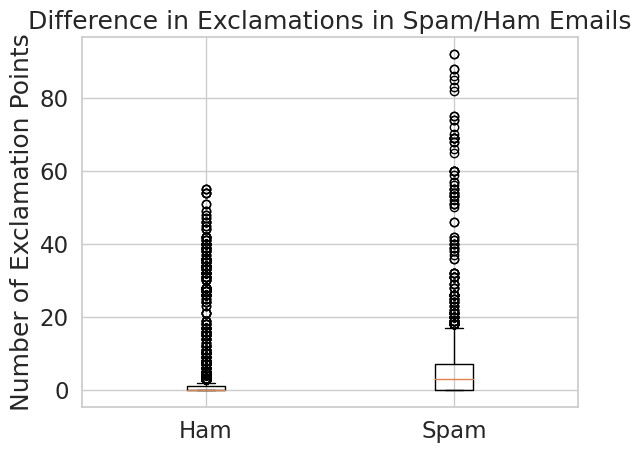

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

h_excl = train[train['spam'] == 0]['email'].str.count('!')
s_excl = train[train['spam'] == 1]['email'].str.count('!')
h_excl = h_excl[h_excl < 100]
s_excl = s_excl[s_excl < 100]

plt.boxplot([h_excl, s_excl])
plt.ylabel('Number of Exclamation Points')
plt.title('Difference in Exclamations in Spam/Ham Emails')
plt.xticks([1, 2], ['Ham', 'Spam'])

In [ ]:
# import libraries
# You may use any of these to create your features.
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, roc_curve, confusion_matrix
from sklearn.model_selection import GridSearchCV
from sklearn.decomposition import PCA
import re
from collections import Counter

In [ ]:
# Define your processing function, processed data, and model here.
# You may find it helpful to look through the rest of the questions first!
def count_uppercase_chars_in_string(s):
    return sum(1 for char in s if char.isupper())

def total_uppercase_in_array(words):
    total_count = 0
    for word in words:
        total_count += count_uppercase_chars_in_string(word)
    return total_count

selected_words = ['winner', 'head', 'free', 'prize', 'winner', '<html>', '<', '>', 'url']
exclamation_points = np.array(train['email'].apply(lambda x: x.count('!')))
word_matrix = words_in_texts(selected_words, train['email'])
uppercase_num = np.array(train['subject'].apply(lambda subj: total_uppercase_in_array(subj.split())))

train_features = np.column_stack([exclamation_points, word_matrix, uppercase_num])
train_labels = train['spam']

log_reg_model = LogisticRegression(fit_intercept=True, penalty='l2', max_iter=1000)

log_reg_model.fit(train_features, train_labels)

model_accuracy = log_reg_model.score(train_features, train_labels)

In [ ]:
train_predictions = log_reg_model.predict(train_features)

# Print your training accuracy.
training_accuracy = np.mean(train_predictions == train["spam"])
training_accuracy

0.8660987621456143

In [ ]:
# @title
grader.check("q3a")

In [ ]:
test_exclamation_points = np.array(test['email'].apply(lambda x: x.count('!')))
test_word_matrix = words_in_texts(selected_words, test['email'])

test_uppercase_num = np.zeros(len(test))
for i, subj in enumerate(test['subject']):
    if isinstance(subj, str):
        test_uppercase_num[i] = total_uppercase_in_array(subj.split())
    else:
        test_uppercase_num[i] = 0

X_test = np.column_stack([test_exclamation_points, test_word_matrix, test_uppercase_num])

test_predictions = log_reg_model.predict(X_test)

In [ ]:
# @title
grader.check("q3b")

In [ ]:
# Assuming that your predictions on the test set are stored in a 1-dimensional array called
# test_predictions. Feel free to modify this cell as long you create a CSV in the right format.

# Construct and save the submission:
submission_df = pd.DataFrame({
    "Id": test['id'],
    "Class": test_predictions,
}, columns=['Id', 'Class'])
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
filename = "submission_{}.csv".format(timestamp)
submission_df.to_csv(filename, index=False)

print('Created a CSV file: {}.'.format("submission_{}.csv".format(timestamp)))
display(HTML("Download your test prediction <a href='" + filename + "' download>here</a>."))
print('You may now upload this CSV file to Gradescope for scoring.')#

Created a CSV file: submission_20240427_061912.csv.


You may now upload this CSV file to Gradescope for scoring.


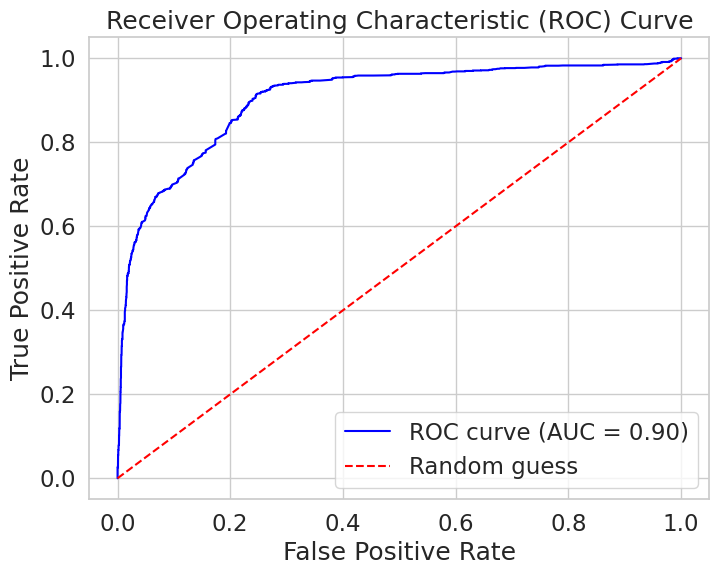

In [ ]:
from sklearn.metrics import roc_curve, auc

y_pred_proba = log_reg_model.predict_proba(train_features)[:, 1]


fpr, tpr, thresholds = roc_curve(train_labels, y_pred_proba)

roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='red', linestyle='--', label='Random guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.show()

In [ ]:
# Just run this cell, don't modify it.

print("spam: " + str(train.loc[5216]["spam"]))
print("\nemail:\n" + train.loc[5216]["email"])

spam: 1

email:
hello you two,
 
 i am so sorry catherine for not writing recently. i have just been vv busybeing a working mother and sometimes it all gets too much you know!! i cannot wait to see you both although we may meet at the airport on the 16/6 as that's the day we're going to france but i will see you both at bronagh's house for her 30th which we're going to on the way back from the airport. i am so excited about seeing you!!! liitle eva ( aine) was born on tuesday
  she is absolutely incredible. poor bronagh is 11 dsays over!!
 sounds like you've been having an amazing time. hope you won't be too depressed to be back!!
 
 lots of love
 
 deirdre
 "justin mason" <jm@jmason.org> wrote:
 
 <  
 <  just a quick note -
 <  
 <  we've decided to go up to annapurna base camp instead of
 <  the jomsom trek - it's a bit more impressive visually
 <  (if a little soggier).   so as of tomorrow morning, ourselves
 <  and our guide bhadra will be leaping like gazelles up 4000-odd
 <  met

In [ ]:
# Just run this cell, don't modify it.

print("spam: " + str(train.loc[36]["spam"]))
print("\nemail:\n" + train.loc[36]["email"])

spam: 0

email:
lifetime movie newsletter
 
 this week's movies to watch on lifetime
 
 [ http://www.lifetimetv.com/movies/index.html ]
 
 august 19, 2002
 
 *************************************************************************
 
 coming at you this week...
 
 1) "the secret life of zoey" premiere!
 2) the buzz about the upcoming movie
 3) movies airing this week
 4) big event: a martinez sunday
 5) fun and games
 
 *************************************************************************
 
 "the secret life of zoey" premiere!
 
 take a sneak peek at lifetimes next exciting original movie, "the secret life of zoey" [ http://www.lifetimetv.com/movies/info/move3195.html ], airing on monday, august 19 at 9 pm et/pt. zoey's mom thought she knew everything about her perfect teenage daughter. but when she realizes that her child is addicted to drugs, both of their worlds spin out of control. this dramatic film delves into the topic of teenage drug addiction and features stellar performer

In [ ]:
# Just run this cell, don't modify it.

print("spam: " + str(train.loc[1092]["spam"]))
print("\nemail:\n" + train.loc[1092]["email"])

spam: 0

email:
this is a multi part message in mime format.
 
 --_nextpart_1_bvfoditvghtocxfdvjnkcuwblfv
 content-type: text/plain; charset="us-ascii"
 content-transfer-encoding: 7bit
 
 ........... with our telecoms partner bumblebee !
 
 don't get ripped off by expensive hotel, payphone and mobile charges. 
 save, save, save on international calls with ryanair's phone partner. 
 ************************************************************************
 *********
 
 you'll save up to 70% on international phone calls when you use our 
 online phone card.  you can use the card from any phone in any country 
 you visit and you won't have to worry about high phone charges 
 when you call home or the office.
 
 buying a card couldn't be easier and it's totally secure.  simply go to
 http://www.bumblebeecommunications.com/lowcostcalls/  
  to avail of this special offer for ryanair customers.
 
 it's another great deal from ryanair and our online phone 
 partner, bumblebee communications. 


In [ ]:
# Simple model introduced at the start of this notebook. Just pay attention to the features.
some_words = ['drug', 'bank', 'prescription', 'memo', 'private']

X_train = words_in_texts(some_words, train['email'])
Y_train = np.array(train['spam'])

simple_model = LogisticRegression()
simple_model.fit(X_train, Y_train);

In [ ]:
email_idx = 50

prob_spam = simple_model.predict_proba(X_train)[:, 1]
initial_prob = prob_spam[email_idx]
initial_class = "spam" if np.round(initial_prob) else "ham"
print(f"\nPredicted probability of being spam: {np.round(initial_prob*100, 2)}%")
print("\nEmail:\n" + train.loc[email_idx]["email"])


Predicted probability of being spam: 55.57%

Email:
<html>
 <head>
 <title>igtt</title>
 <meta http-equiv="content-type" content="text/html; charset=iso-8859-1">
 </head>
 <body bgcolor="#ffffff" text="#000000">
 <img src="http://www.developerhosting.com/lqtracker/imgtrk.asp?id=40165&uid=1290" width="1" height="1" border="0"> 
 <div align="center">
 <table width="92%" border="1" bordercolor="#333333">
 <tr> 
 <td height="23"> 
 <div align="center">
 <div align="center">
 <div align="center"> 
 <div align="center">
 <p align="right"><font color="#000000" size="2" face="courier new, courier, mono">vol. 
 6, issue 243 - august 2002</font></p>
 <p><font size="6"><font face="impact" size="7" color="#ff0000">the 
 wall street bulletin</font></font></p>
 </div>
 <div align="center"><font color="#ff0000"><i><font size="4" face="times new roman, times, serif"><b><font size="3">your 
 first source for news from &quot;the street&quot;</font></b></font></i></font></div>
 <p align="center">symbol:

In [ ]:
feature_to_remove = 'bank'

changed_words = some_words.copy()
changed_words.remove(feature_to_remove)

changed_model = LogisticRegression()
X_changed = words_in_texts(changed_words, train['email'])
y = train['spam']
changed_model.fit(X_changed, y)
changed_prob = changed_model.predict_proba(X_changed[[email_idx]])[:,1][0]
changed_class = "spam" if np.round(changed_prob) else "ham"

print(f"Initially classified as {initial_class} (Probability: {np.round(initial_prob*100, 2)}%)")
print(f"Now classified as {changed_class} (Probability: {np.round(changed_prob*100, 2)}%)")

Initially classified as spam (Probability: 55.57%)
Now classified as ham (Probability: 24.33%)


In [ ]:
# @title
grader.check("q7ai")

In [ ]:
# @title
# Save your notebook first, then run this cell to export your submission.
grader.export(run_tests=True)